In [54]:
import pandas as pd
from sqlalchemy import create_engine, inspect, select
from sqlalchemy.orm import declarative_base, relationship, sessionmaker
from create_db import config_local
from create_db.data_classes import (
    Player,
    PlayerStat,
    MVPCandidate,
    MVPWinner,
    AdvancedStat,
    TeamPerformance,
    Roster,
    SeasonStat,
    Team,
)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.ticker import PercentFormatter
import numpy as np
from PIL import Image
import pathlib


In [ ]:
plt.rcParams["figure.dpi"] = 200
plt.rcParams["figure.figsize"] = (12.8, 7.2)
plt.style.use("seaborn-v0_8-white")
sns.set_theme(style="white")
warnings.filterwarnings(
    "ignore", message="Glyph .* missing from font", category=UserWarning
)

In [ ]:
target_size = (300, 300)
for path in pathlib.Path("data_analysis/Anoosha/assets").glob("*.png"):
    img = Image.open(path)
    img = img.resize(target_size, Image.LANCZOS)
    img.save(path)


In [3]:
###setting up the engine
DB_USER, DB_PASSWORD, DB_HOST, DB_PORT, DB_NAME = (
    config_local.DB_USER,
    config_local.DB_PASSWORD,
    config_local.DB_HOST,
    config_local.DB_PORT,
    config_local.DB_NAME,
)


Base = declarative_base()
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True,
)
SessionLocal = sessionmaker(bind=engine)
session = SessionLocal()

insp = inspect(engine)

In [4]:
for model in (
    Player,
    PlayerStat,
    MVPCandidate,
    MVPWinner,
    AdvancedStat,
    PlayerStat,
    TeamPerformance,
    Roster,
    SeasonStat,
    Team,
):
    mapper = inspect(model)
    print(model.__tablename__)
    print(mapper.columns.keys())
    print("relationships:", mapper.relationships.keys())
    print("-" * 25)


players
['player_id', 'player_name', 'shoots', 'draft_team_name', 'experience', 'nba_debut', 'position_1', 'position_2', 'position_3', 'position_4', 'position_5', 'position_6', 'draft_year', 'height_cm', 'weight_kg', 'age', 'draft_round_pick_rank', 'draft_overall_pick_rank', 'career_points', 'career_total_rebound_pct', 'career_assists_pct', 'career_field_goal_pct', 'career_three_point_pct', 'career_free_throw_pct', 'career_effective_fg_pct', 'career_per', 'career_win_shares']
relationships: ['playerstats', 'mvp_finishes', 'mvp_titles', 'rosters', 'advanced_stats']
-------------------------
player_stats
['season', 'player_id', 'rank', 'age', 'team_id', 'position', 'games_played', 'games_started', 'minutes_played', 'field_goals_made', 'field_goals_attempted', 'field_goal_pct', 'three_pointers_made', 'three_pointers_attempted', 'three_point_pct', 'two_pointers_made', 'two_pointers_attempted', 'two_point_pct', 'effective_fg_pct', 'free_throws_made', 'free_throws_attempted', 'free_throw_pct

Usage vs efficiency (“superstar tax”): do players TS% drop as USG% rises, and who stays efficient at high usage?

In [5]:
with session:
    stmt = (
        select(
            Player.player_id,
            Player.player_name,
            AdvancedStat.usage_percentage,
            AdvancedStat.true_shooting_percentage,
            PlayerStat.rank,
            PlayerStat.season,
        )
        .join(Player.playerstats)
        .join(
            AdvancedStat,
            (AdvancedStat.player_id == PlayerStat.player_id)
            & (AdvancedStat.season == PlayerStat.season),
        )
        .where(PlayerStat.minutes_played >= 1000, PlayerStat.rank <= 10)
    )
    usage_effic_df = pd.read_sql(stmt, session.get_bind())


In [ ]:
def plot_superstar_tax_top10():
    plot_df = usage_effic_df.copy()
    plot_df["ts_pct"] = plot_df["true_shooting_percentage"] * 100
    g = sns.relplot(
        data=plot_df,
        x="usage_percentage",
        y="ts_pct",
        hue="season",
        col="player_name",
        col_wrap=6,
        height=4.8,
        aspect=1.0,
        palette="viridis",
        facet_kws=dict(sharex=True, sharey=True),
        s=140,
    )

    g.set_axis_labels("Usage Percentage %", "True Shooting Percentage %")
    g.set(xlim=(0, 70), ylim=(0, 70))
    g.set_titles("{col_name}", fontweight="bold", fontsize="14")
    g.set_axis_labels("", "")
    g.figure.supxlabel("Usage Percentage %", y=0.00, fontweight="bold", fontsize="14")
    g.figure.supylabel(
        "True Shooting Percentage %", x=0.003, fontweight="bold", fontsize="14"
    )
    g.fig.suptitle(
        "Superstar Tax for Top 10 Players ( 2019 - 2025 )",
        fontsize=15,
        fontweight="bold",
        y=1.02,
    )
    legend = g._legend
    legend.set_title("Season")
    legend.get_title().set_fontsize(16)

    for text in legend.get_texts():
        text.set_fontsize(14)

    g.tight_layout()
    plt.show()

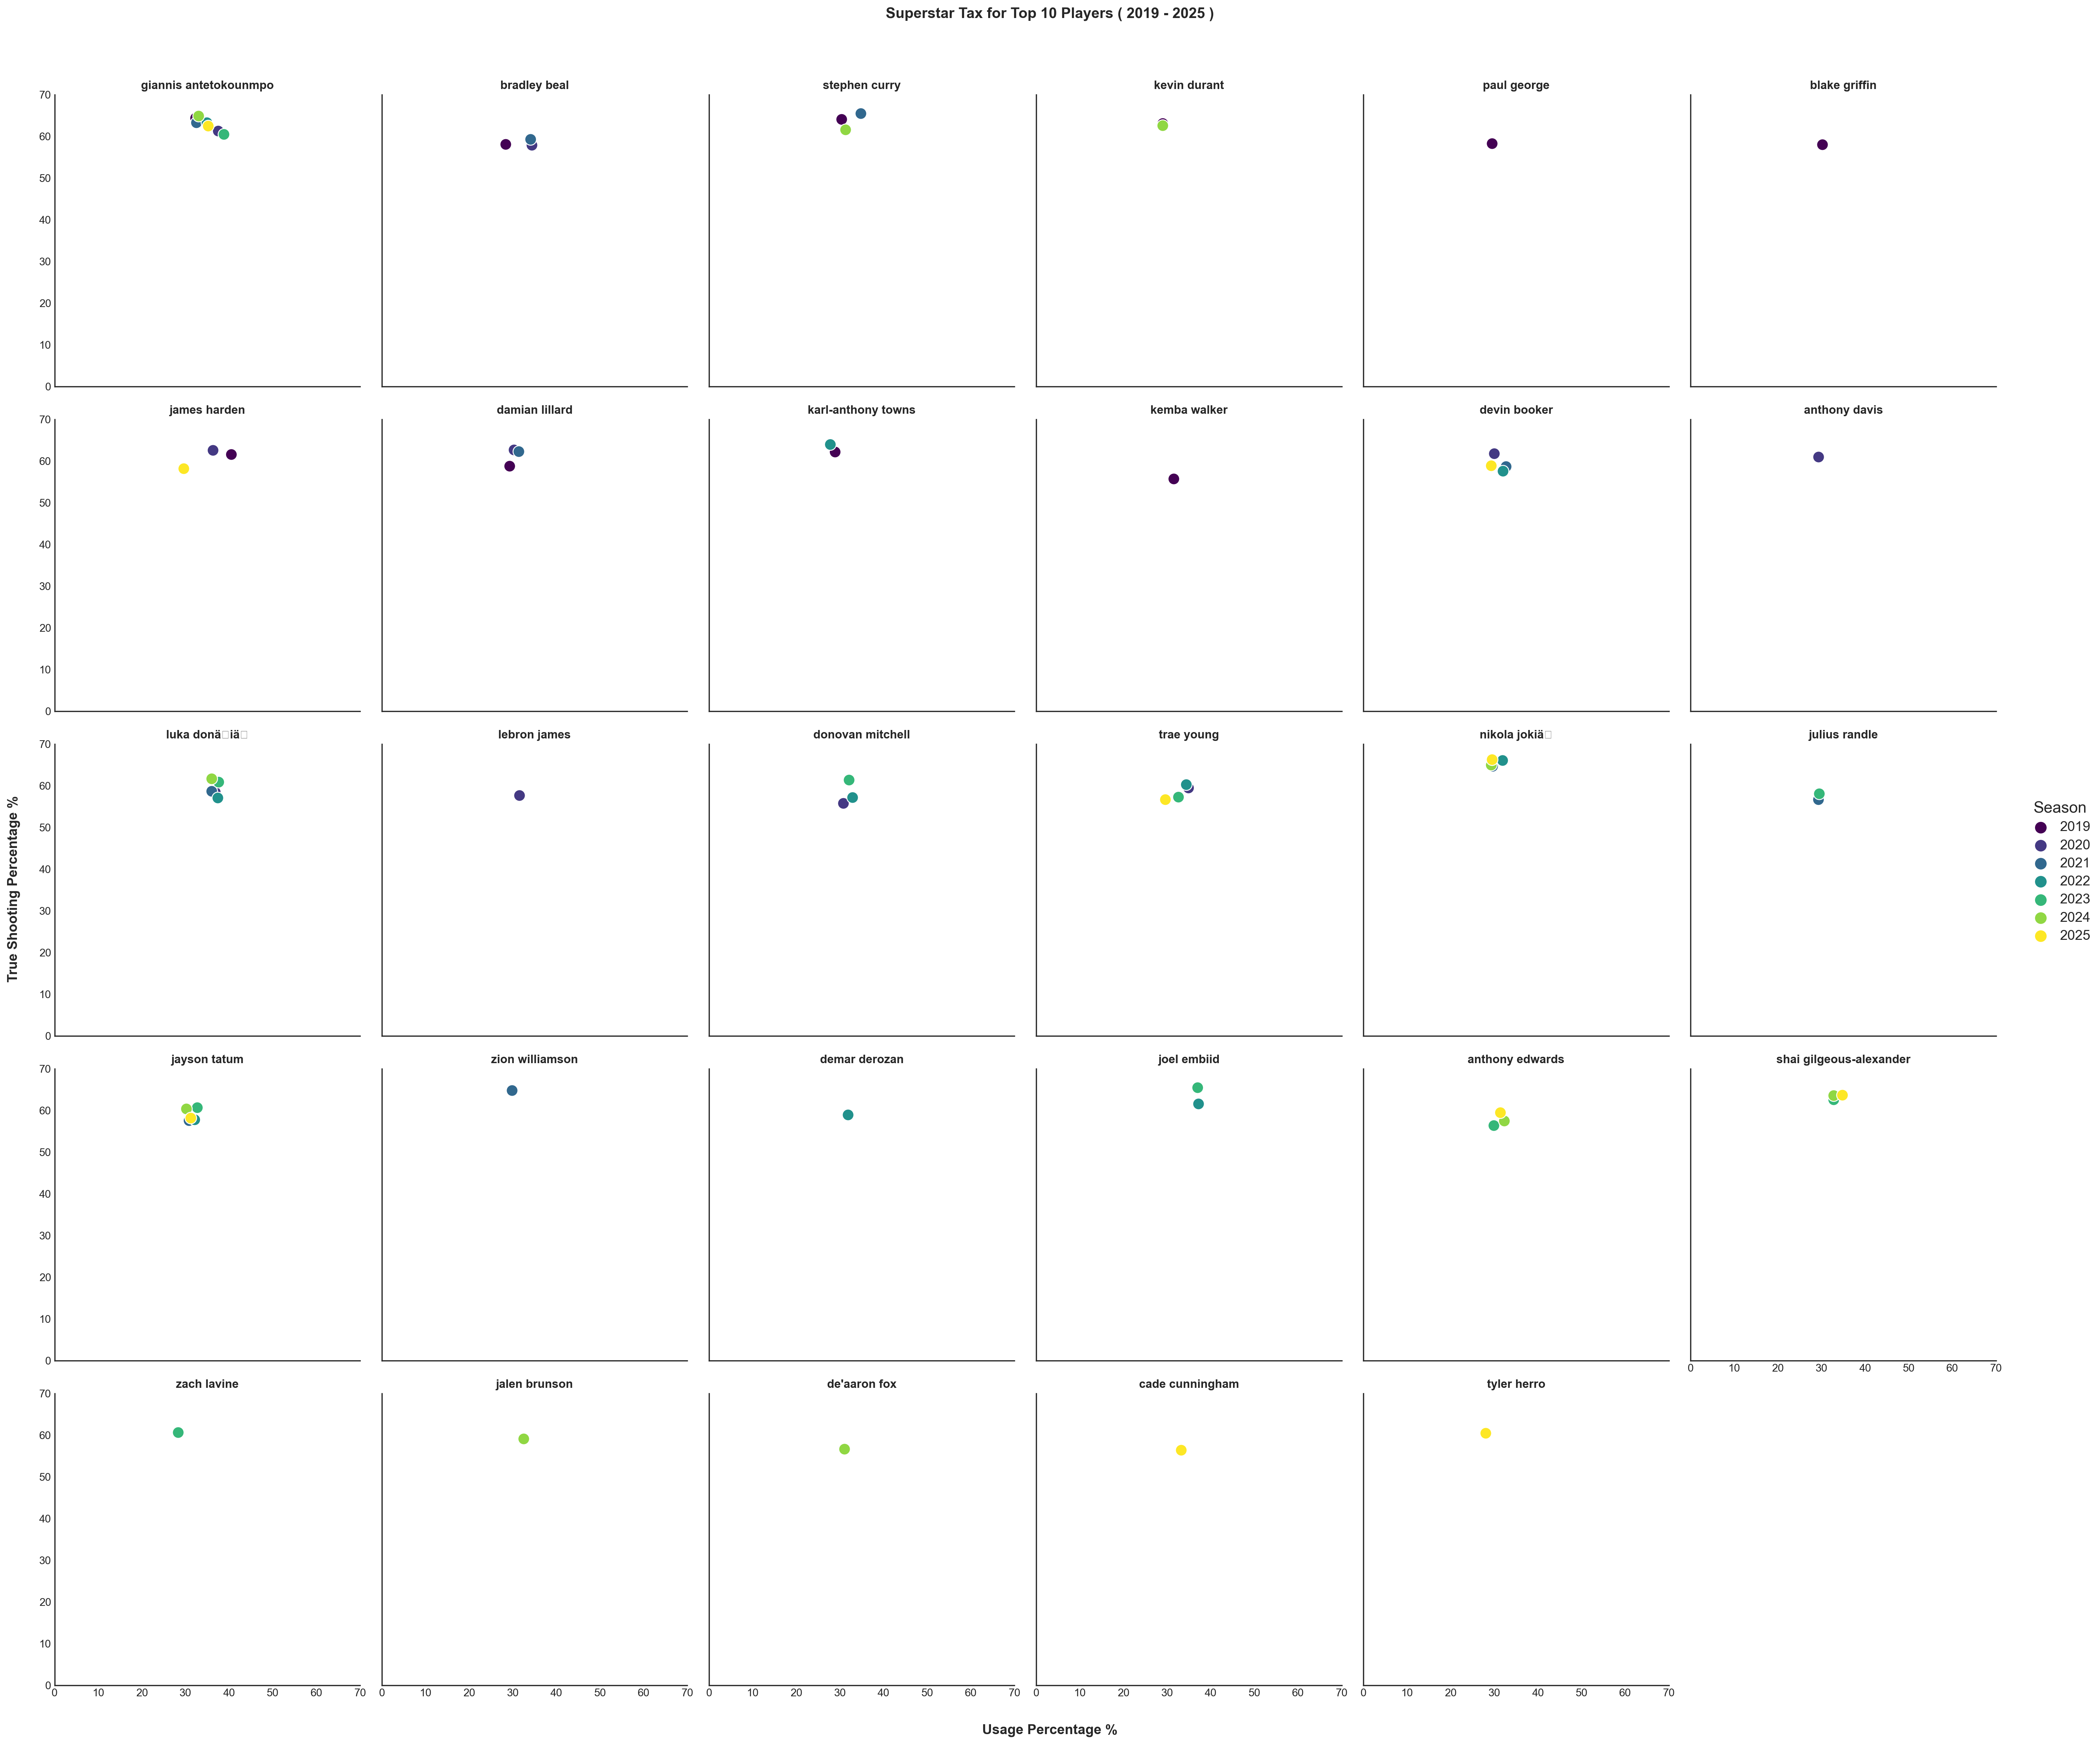

In [95]:
plot_superstar_tax_top10()

In [10]:
players = ["giannis antetokounmpo", "james harden", "jayson tatum", "trae young"]

In [ ]:
def plot_superstar_tax():
    # plt.style.use("seaborn-v0_8-white")
    fig, ax = plt.subplots(2, 3, figsize=(18, 12), sharex=True, sharey=True)

    giannis = usage_effic_df[
        usage_effic_df["player_name"] == "giannis antetokounmpo"
    ].copy()
    giannis["ts_pct"] = giannis["true_shooting_percentage"] * 100
    sns.scatterplot(
        ax=ax[0, 0],
        data=giannis,
        x="usage_percentage",
        y="ts_pct",
        hue="season",
        palette="viridis",
        s=120,
    )
    ax[0, 0].set_xlim(0, 100)
    ax[0, 0].set_ylim(0, 100)
    ax[0, 0].set_xlabel("Usage Percentage %", fontweight="bold")
    ax[0, 0].set_ylabel("True Shooting Percentage %", fontweight="bold")
    ax[0, 0].set_title("Giannis Antetokounmpo", fontweight="bold")
    sns.despine(ax=ax[0, 0])
    logo = plt.imread("data_analysis/Anoosha/assets/gianni.png")
    ax[0, 0].add_artist(
        AnnotationBbox(
            OffsetImage(logo, zoom=0.7),
            (0.97, 0.05),
            frameon=False,
            xycoords="axes fraction",
            box_alignment=(1, 0),
        )
    )

    Harden = usage_effic_df[usage_effic_df["player_name"] == "james harden"].copy()
    Harden["ts_pct"] = Harden["true_shooting_percentage"] * 100
    sns.scatterplot(
        ax=ax[0, 1],
        data=Harden,
        x="usage_percentage",
        y="ts_pct",
        hue="season",
        palette="viridis",
        s=120,
    )
    ax[0, 1].set_xlim(0, 100)
    ax[0, 1].set_ylim(0, 100)
    ax[0, 1].set_xlabel("Usage Percentage %", fontweight="bold")
    ax[0, 1].set_ylabel("True Shooting Percentage %", fontweight="bold")
    ax[0, 1].set_title("James Harden", fontweight="bold")
    sns.despine(ax=ax[0, 1])
    logo = plt.imread("data_analysis/Anoosha/assets/harden.png")
    ax[0, 1].add_artist(
        AnnotationBbox(
            OffsetImage(logo, zoom=0.7),
            (0.97, 0.05),
            frameon=False,
            xycoords="axes fraction",
            box_alignment=(1, 0),
        )
    )

    tatum = usage_effic_df[usage_effic_df["player_name"] == "jayson tatum"].copy()
    tatum["ts_pct"] = tatum["true_shooting_percentage"] * 100
    sns.scatterplot(
        ax=ax[0, 2],
        data=tatum,
        x="usage_percentage",
        y="ts_pct",
        hue="season",
        palette="viridis",
        s=120,
    )
    ax[0, 2].set_xlim(0, 100)
    ax[0, 2].set_ylim(0, 100)
    ax[0, 2].set_xlabel("Usage Percentage %", fontweight="bold")
    ax[0, 2].set_ylabel("True Shooting Percentage %", fontweight="bold")
    ax[0, 2].set_title("Jayson Tatum", fontweight="bold")
    sns.despine(ax=ax[0, 2])
    logo = plt.imread("data_analysis/Anoosha/assets/tatum.png")
    ax[0, 2].add_artist(
        AnnotationBbox(
            OffsetImage(logo, zoom=0.6),
            (0.97, 0.05),
            frameon=False,
            xycoords="axes fraction",
            box_alignment=(1, 0),
        )
    )

    young = usage_effic_df[usage_effic_df["player_name"] == "trae young"].copy()
    young["ts_pct"] = young["true_shooting_percentage"] * 100
    sns.scatterplot(
        ax=ax[1, 0],
        data=young,
        x="usage_percentage",
        y="ts_pct",
        hue="season",
        palette="viridis",
        s=120,
    )
    ax[1, 0].set_xlim(0, 100)
    ax[1, 0].set_ylim(0, 100)
    ax[1, 0].set_xlabel("Usage Percentage %", fontweight="bold")
    ax[1, 0].set_ylabel("True Shooting Percentage %", fontweight="bold")
    ax[1, 0].set_title("Trae Young", fontweight="bold")
    sns.despine(ax=ax[1, 0])
    logo = plt.imread("data_analysis/Anoosha/assets/young.png")
    ax[1, 0].add_artist(
        AnnotationBbox(
            OffsetImage(logo, zoom=0.7),
            (0.97, 0.05),
            frameon=False,
            xycoords="axes fraction",
            box_alignment=(1, 0),
        )
    )

    edwards = usage_effic_df[usage_effic_df["player_name"] == "anthony edwards"].copy()
    edwards["ts_pct"] = edwards["true_shooting_percentage"] * 100
    sns.scatterplot(
        ax=ax[1, 1],
        data=edwards,
        x="usage_percentage",
        y="ts_pct",
        hue="season",
        palette="viridis",
        s=120,
    )
    ax[1, 1].set_xlim(0, 100)
    ax[1, 1].set_ylim(0, 100)
    ax[1, 1].set_xlabel("Usage Percentage %", fontweight="bold")
    ax[1, 1].set_ylabel("True Shooting Percentage %", fontweight="bold")
    ax[1, 1].set_title("Anthony Edwards", fontweight="bold")
    sns.despine(ax=ax[1, 1])

    logo = plt.imread("data_analysis/Anoosha/assets/edwards.png")
    ax[1, 1].add_artist(
        AnnotationBbox(
            OffsetImage(logo, zoom=0.7),
            (0.97, 0.05),
            frameon=False,
            xycoords="axes fraction",
            box_alignment=(1, 0),
        )
    )

    ax[1, 2].axis("off")
    fig.tight_layout()
    fig.suptitle(
        "True Shooting vs Usage (2019 - 2025)",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    plt.show()


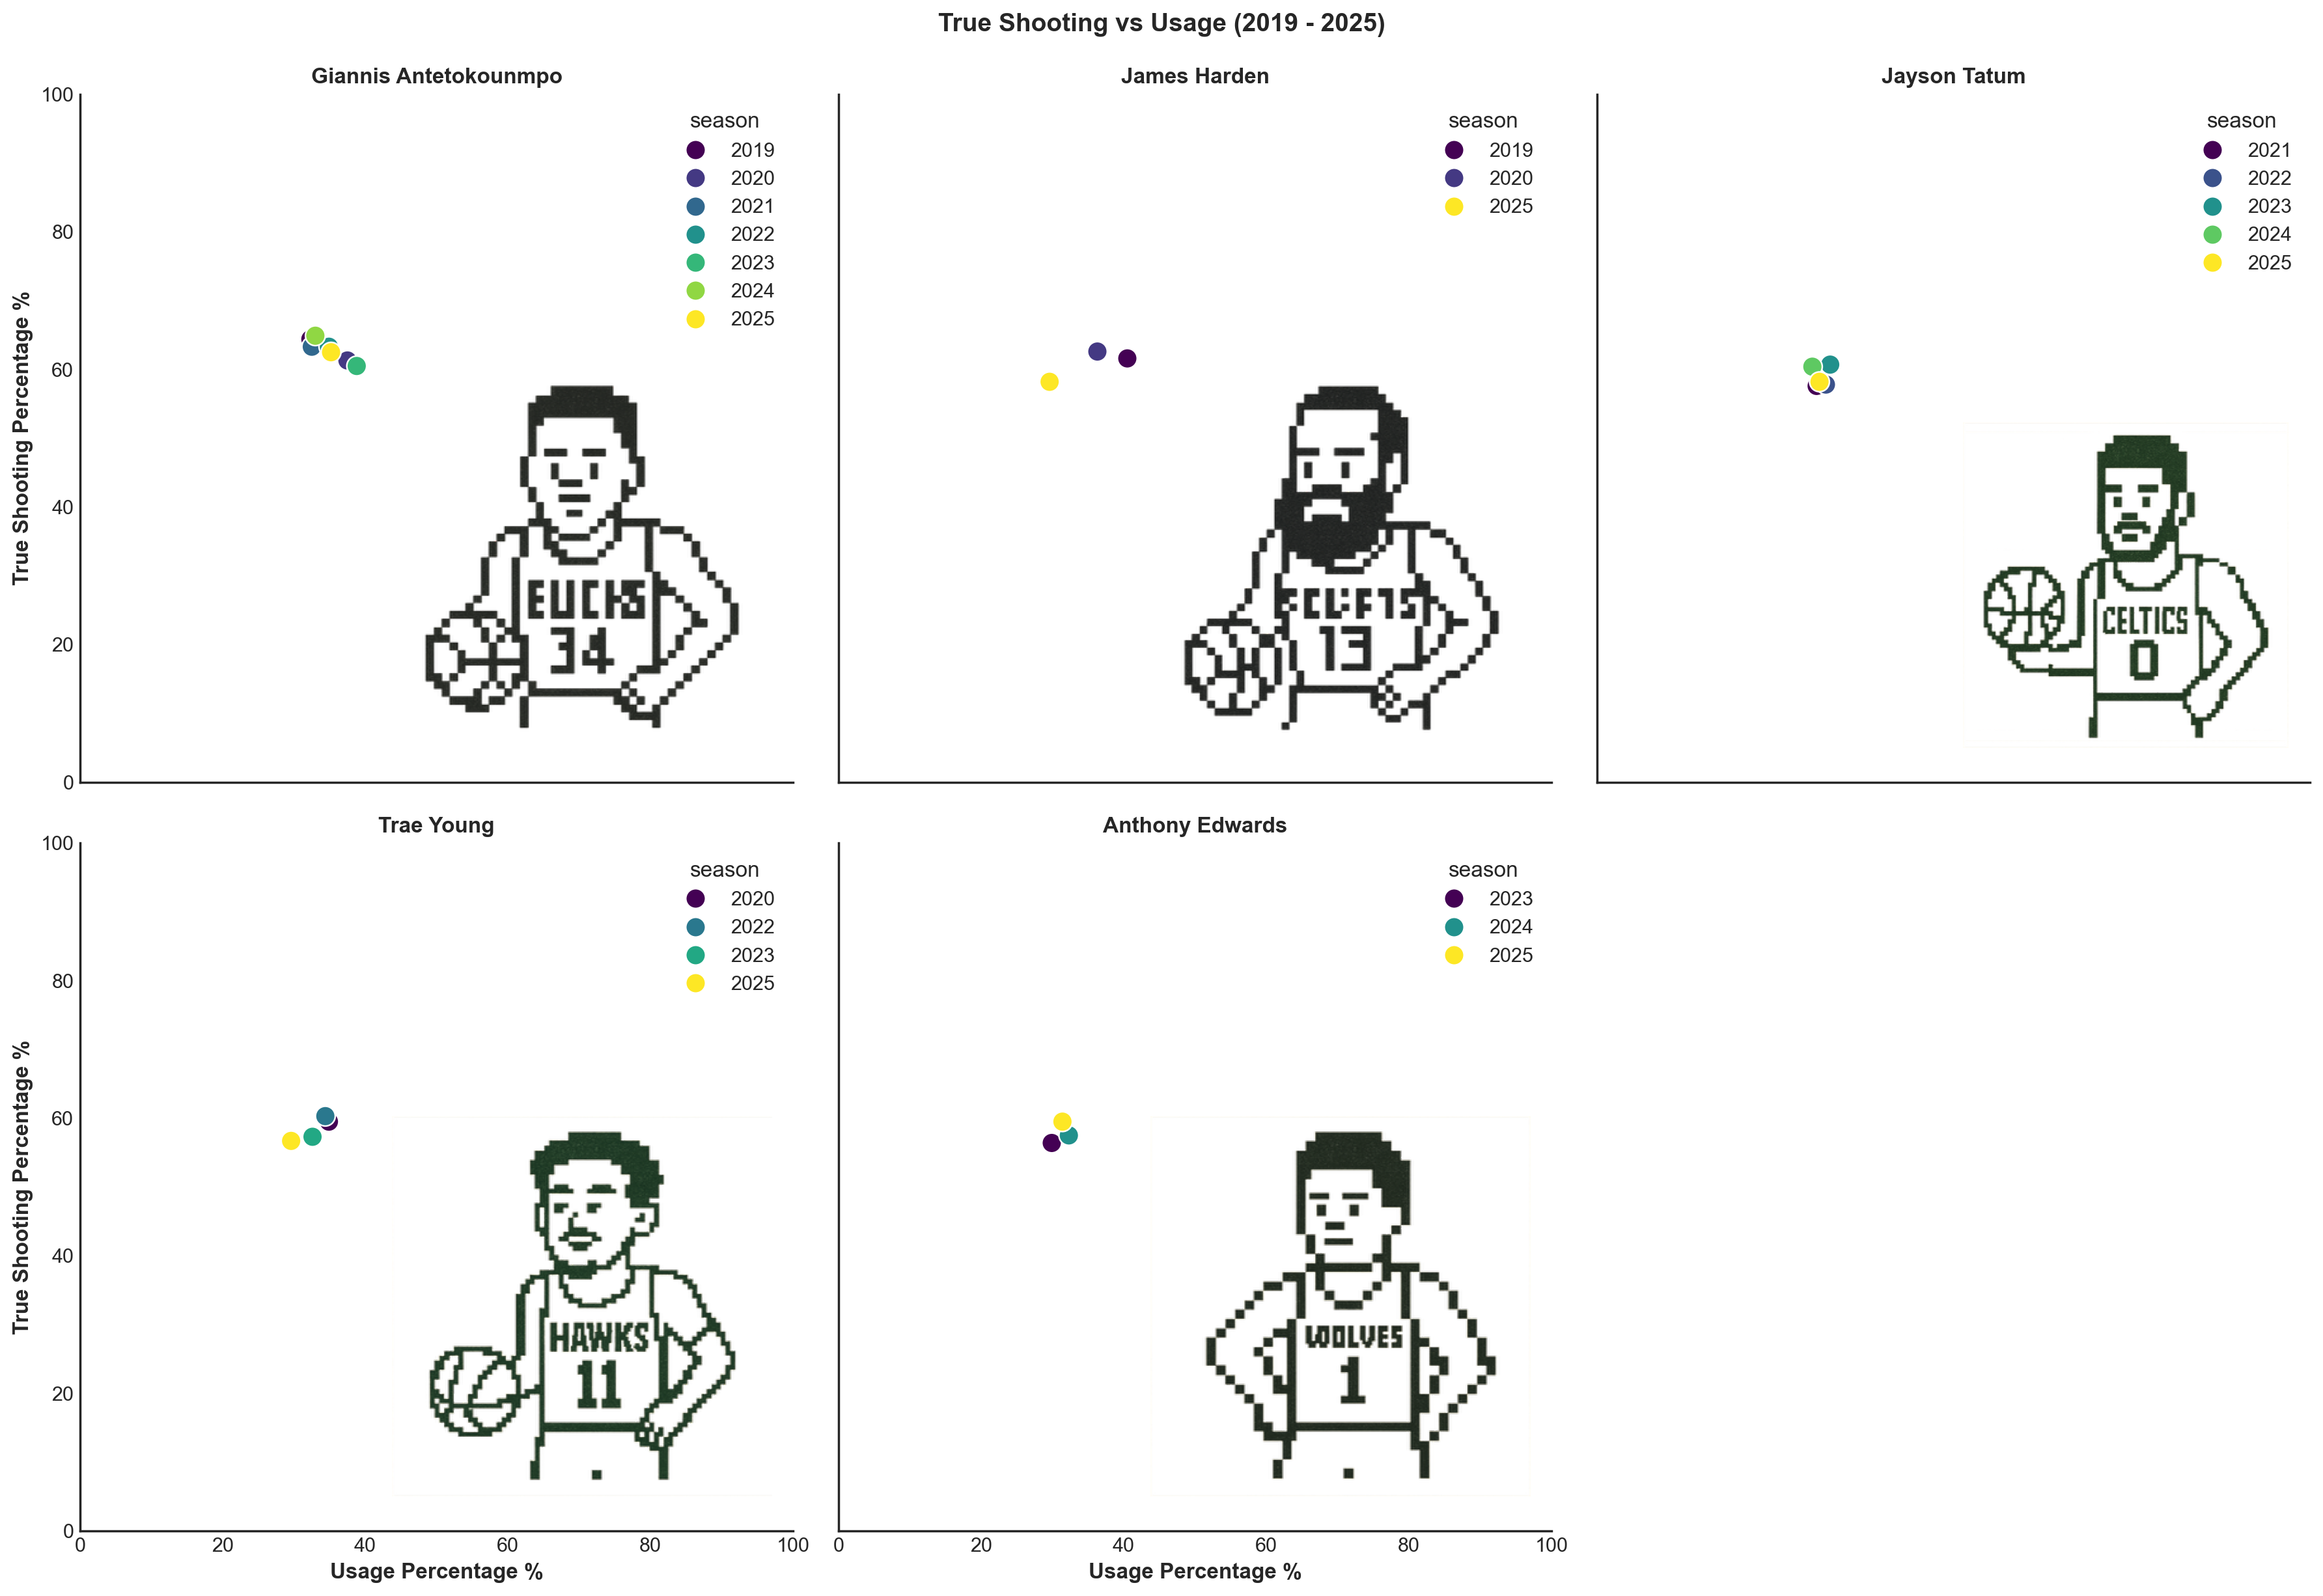

In [99]:
plot_superstar_tax()

What factors drive team performance?

In [100]:
with session:
    stmt = (
        select(*TeamPerformance.__table__.c, Team.team_name)
        .join(TeamPerformance.team)
        .where(TeamPerformance.season.in_([2024, 2025]))
    )

    team_performance = pd.read_sql(stmt, session.get_bind())

In [101]:
team_performance["effective_fg_percentage"] = (
    (
        (
            team_performance["field_goals_made"]
            + (team_performance["three_pointers_made"] * 0.5)
        )
        / team_performance["field_goals_attempted"]
    )
    * 100
).astype(int)


In [102]:
team_performance["estimated_possessions"] = (
    team_performance["field_goals_attempted"]
    - team_performance["offensive_rebounds"]
    + team_performance["turnovers"]
    + (0.44 * team_performance["free_throws_attempted"])
)

In [103]:
team_performance["turnover_pct"] = (
    (team_performance["turnovers"] / team_performance["estimated_possessions"]) * 100
).astype(int)

In [104]:
team_performance["offensive_rebound_pct"] = (
    (
        team_performance["offensive_rebounds"]
        / (
            team_performance["field_goals_attempted"]
            - team_performance["field_goals_made"]
        )
    )
    * 100
).astype(int)

In [105]:
team_performance["free_throw_rate"] = (
    (
        team_performance["free_throws_attempted"]
        / team_performance["field_goals_attempted"]
    )
    * 100
).astype(int)

In [80]:
team_performance.columns

Index(['season', 'team_id', 'rank', 'games', 'minutes_played',
       'field_goals_made', 'field_goals_attempted', 'field_goal_pct',
       'three_pointers_made', 'three_pointers_attempted', 'three_point_pct',
       'two_pointers_made', 'two_pointers_attempted', 'two_point_pct',
       'free_throws_made', 'free_throws_attempted', 'free_throw_pct',
       'offensive_rebounds', 'defensive_rebounds', 'total_rebounds', 'assists',
       'steals', 'blocks', 'turnovers', 'personal_fouls', 'points',
       'team_name', 'effective_fg_percentage', 'estimated_possessions',
       'turnover_pct', 'offensive_rebound_pct', 'free_throw_rate'],
      dtype='object')

In [106]:
team_performance = team_performance[
    [
        "team_name",
        "team_id",
        "season",
        "rank",
        "estimated_possessions",
        "turnover_pct",
        "effective_fg_percentage",
        "offensive_rebound_pct",
        "free_throw_rate",
    ]
]

In [107]:
print(team_performance.head())

                   team_name team_id  season  rank  estimated_possessions  \
0              atlanta hawks     atl    2024     5                8508.64   
1             boston celtics     bos    2024     2                8226.76   
2              brooklyn nets     brk    2024    25                8197.84   
3              chicago bulls     chi    2024    22                8188.64   
4  charlotte hornets (2014-)     cho    2024    28                8162.28   

   turnover_pct  effective_fg_percentage  offensive_rebound_pct  \
0            13                       53                     25   
1            11                       57                     23   
2            13                       53                     23   
3            12                       53                     23   
4            13                       52                     19   

   free_throw_rate  
0               25  
1               22  
2               23  
3               23  
4               21  


In [108]:
team_2024 = team_performance[team_performance["season"] == 2024].copy()
team_2025 = team_performance[team_performance["season"] == 2025].copy()

In [110]:
def fitline(ax, x, y):
    """
    draws a best-fit line for x,y on given matplotlib ax
    """
    m, b = np.polyfit(x, y, 1)
    x2 = [np.min(x), np.max(x)]
    ax.plot(x2, m * np.array(x2) + b, lw=1)


In [111]:
def team_performance_metrics(team_df: pd.DataFrame, season):
    """
    plots four team metrics against their rank in the provided season.
    metrics : effective field goal percentage, offensive rebound percentage, free throw rate and turnover percentage. uses fitline() helper function to draw a best fit line for each subplot.
    """
    fig, ax = plt.subplots(2, 2, sharex=True)

    x = team_df["rank"]
    ax[0, 0].scatter(x, team_df["effective_fg_percentage"])
    ax[0, 0].set_title("Effective Field Goal (%) vs Rank", fontweight="bold")
    ax[0, 0].set_ylim(top=80)
    fitline(ax[0, 0], x, team_df["effective_fg_percentage"])

    ax[0, 1].scatter(x, team_df["offensive_rebound_pct"])
    ax[0, 1].set_title("Offensive Rebound (%) vs Rank", fontweight="bold")
    ax[0, 1].set_ylim(top=50)
    fitline(ax[0, 1], x, team_df["offensive_rebound_pct"])

    ax[1, 0].scatter(x, team_df["free_throw_rate"])
    ax[1, 0].set_title("Free-Throw Rate (%) vs Rank", fontweight="bold")
    ax[1, 0].set_ylim(top=50)
    fitline(ax[1, 0], x, team_df["free_throw_rate"])

    ax[1, 1].scatter(x, team_df["turnover_pct"])
    ax[1, 1].set_title("Turnover (%) vs Rank", fontweight="bold")
    ax[1, 1].set_ylim(top=50)
    fitline(ax[1, 1], x, team_df["turnover_pct"])

    for axes in ax.flat:
        axes.set_ylim(bottom=0)
        axes.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

    sns.despine(fig=fig)
    fig.tight_layout(rect=[0, 0.05, 1, 0.98])

    fig.suptitle(
        (f"NBA {season} Teams Performance"),
        ha="center",
        y=1.05,
        fontsize=15,
        fontweight="bold",
        backgroundcolor="lightgrey",
    )

    fig.supxlabel(
        "Rank",
        x=0.5,
        y=0.03,
        fontsize=13,
        fontweight="bold",
        backgroundcolor="lightgrey",
    )

    fig.supylabel(
        "Percentage (%)",
        x=-0.03,
        fontsize=13,
        fontweight="bold",
        backgroundcolor="lightgrey",
    )

    plt.show()

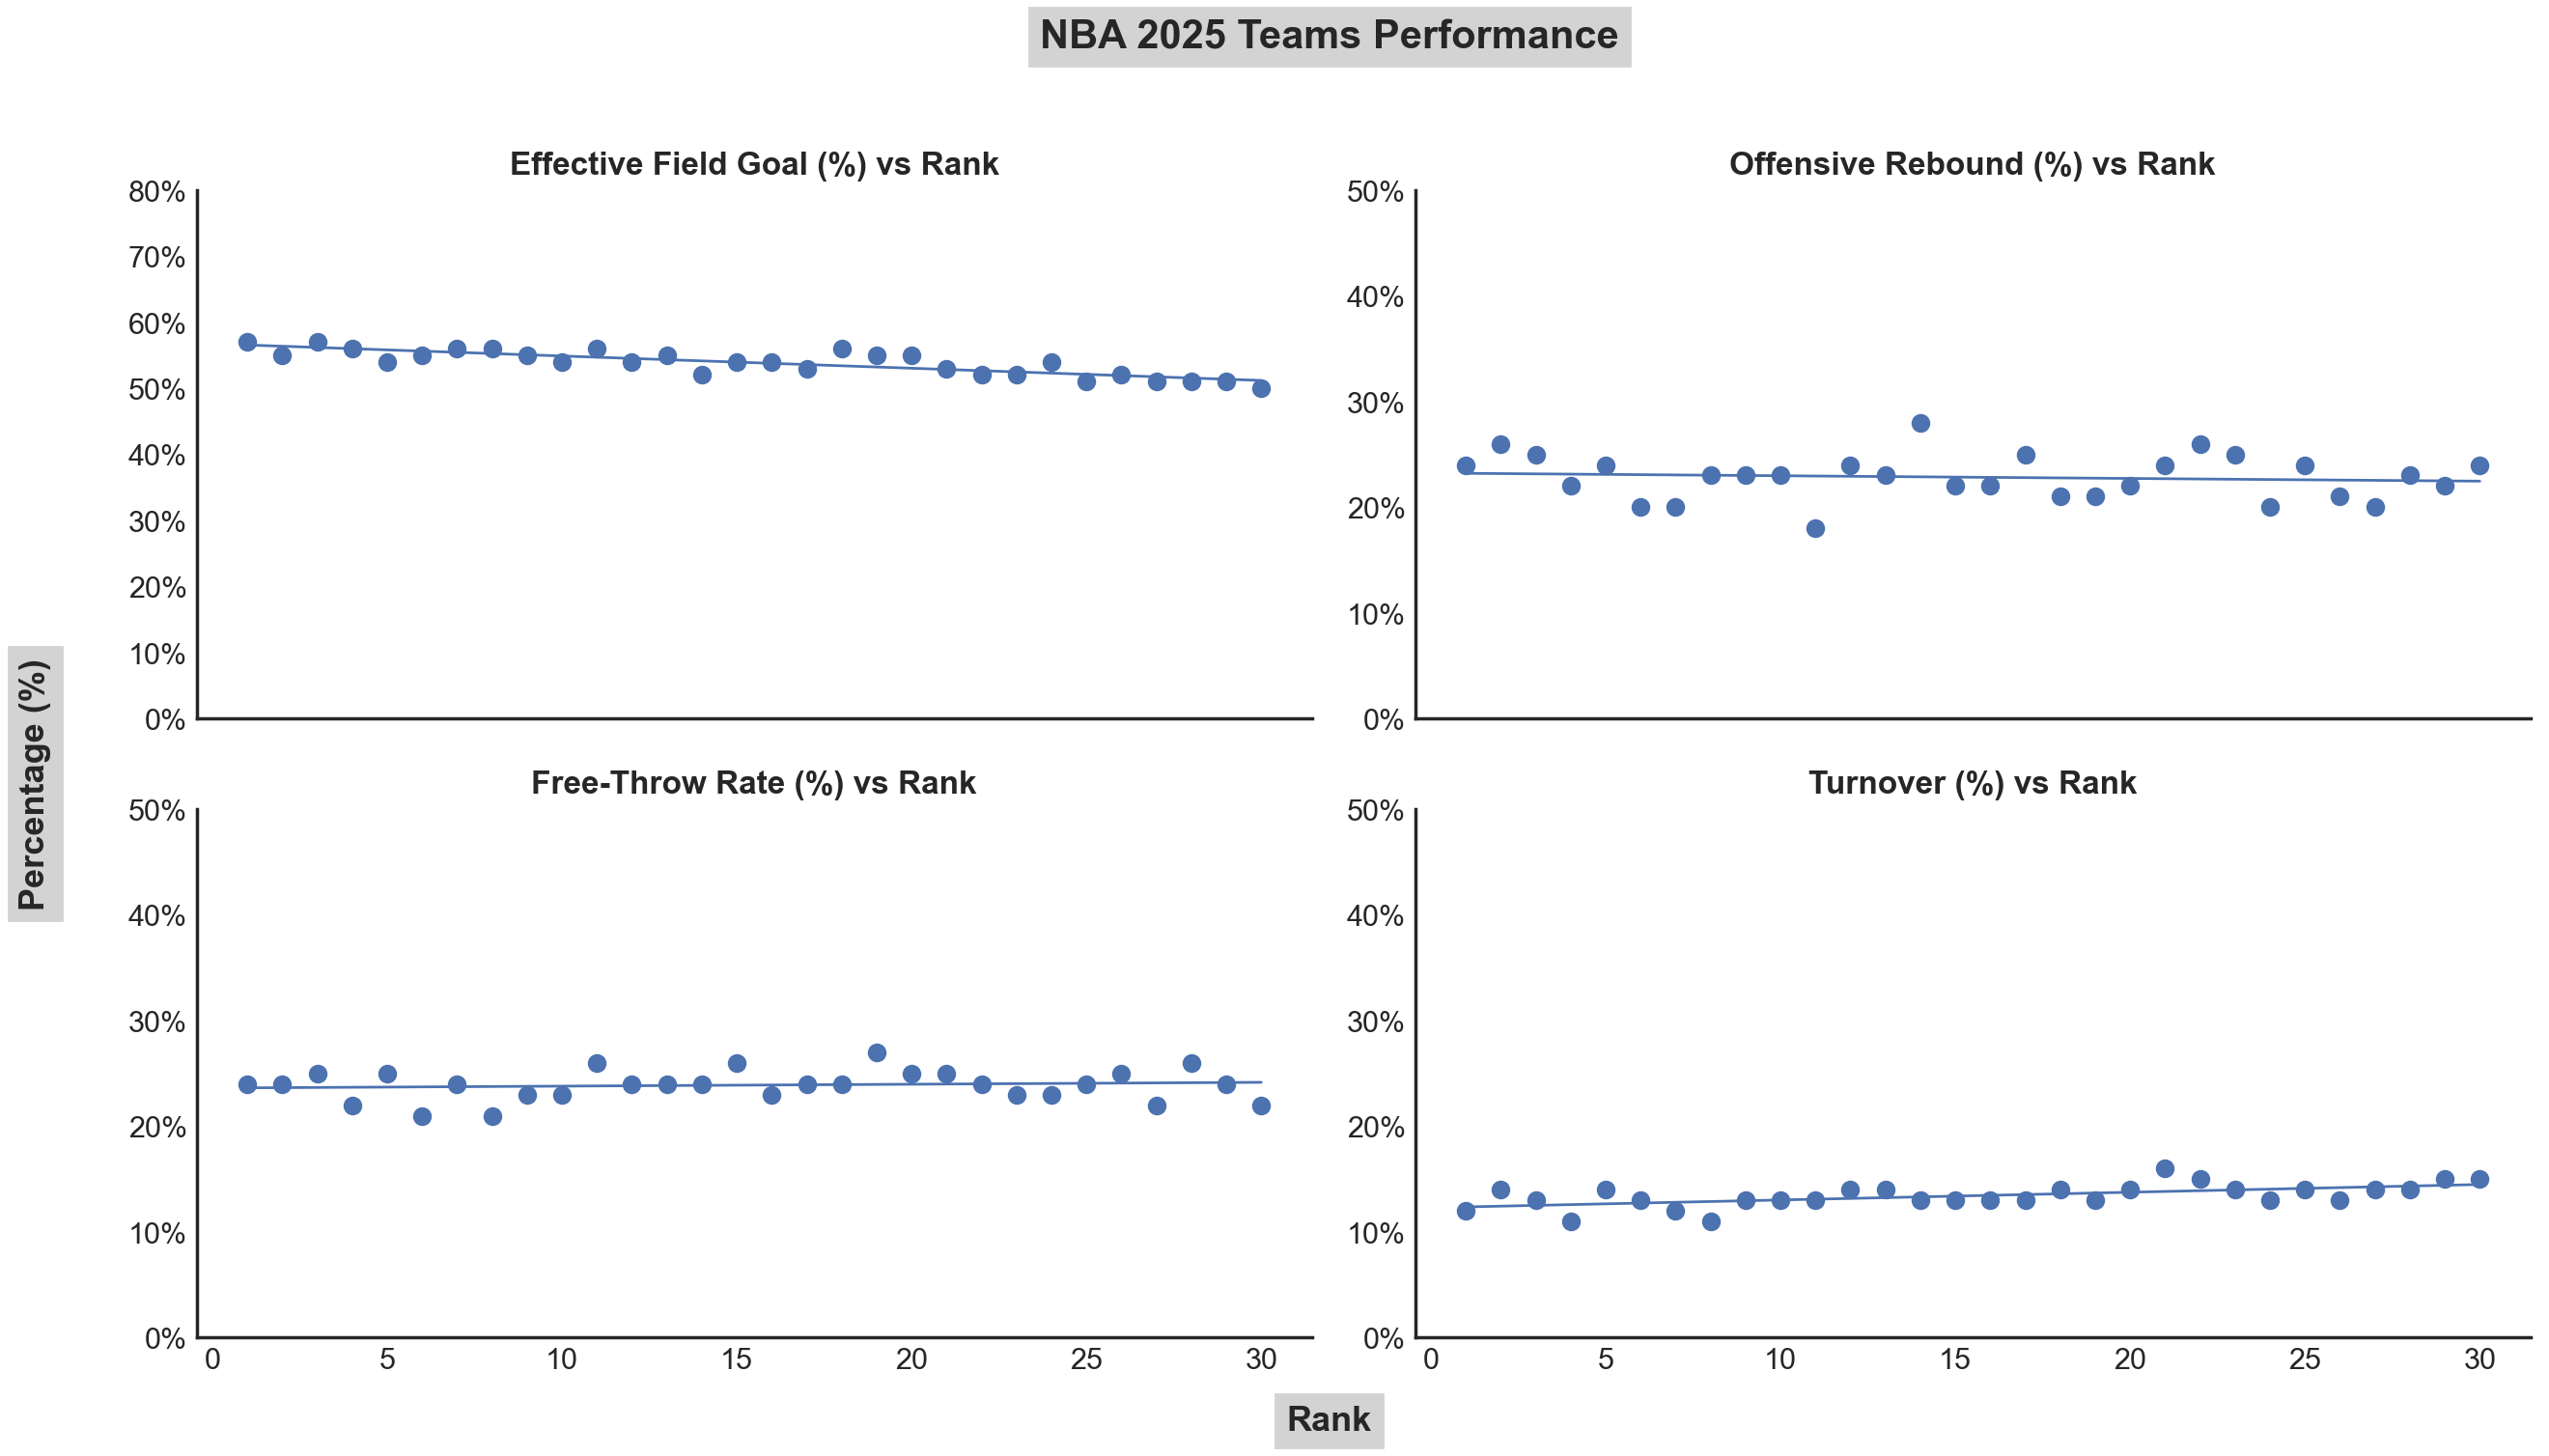

In [112]:
team_performance_metrics(team_2025, 2025)

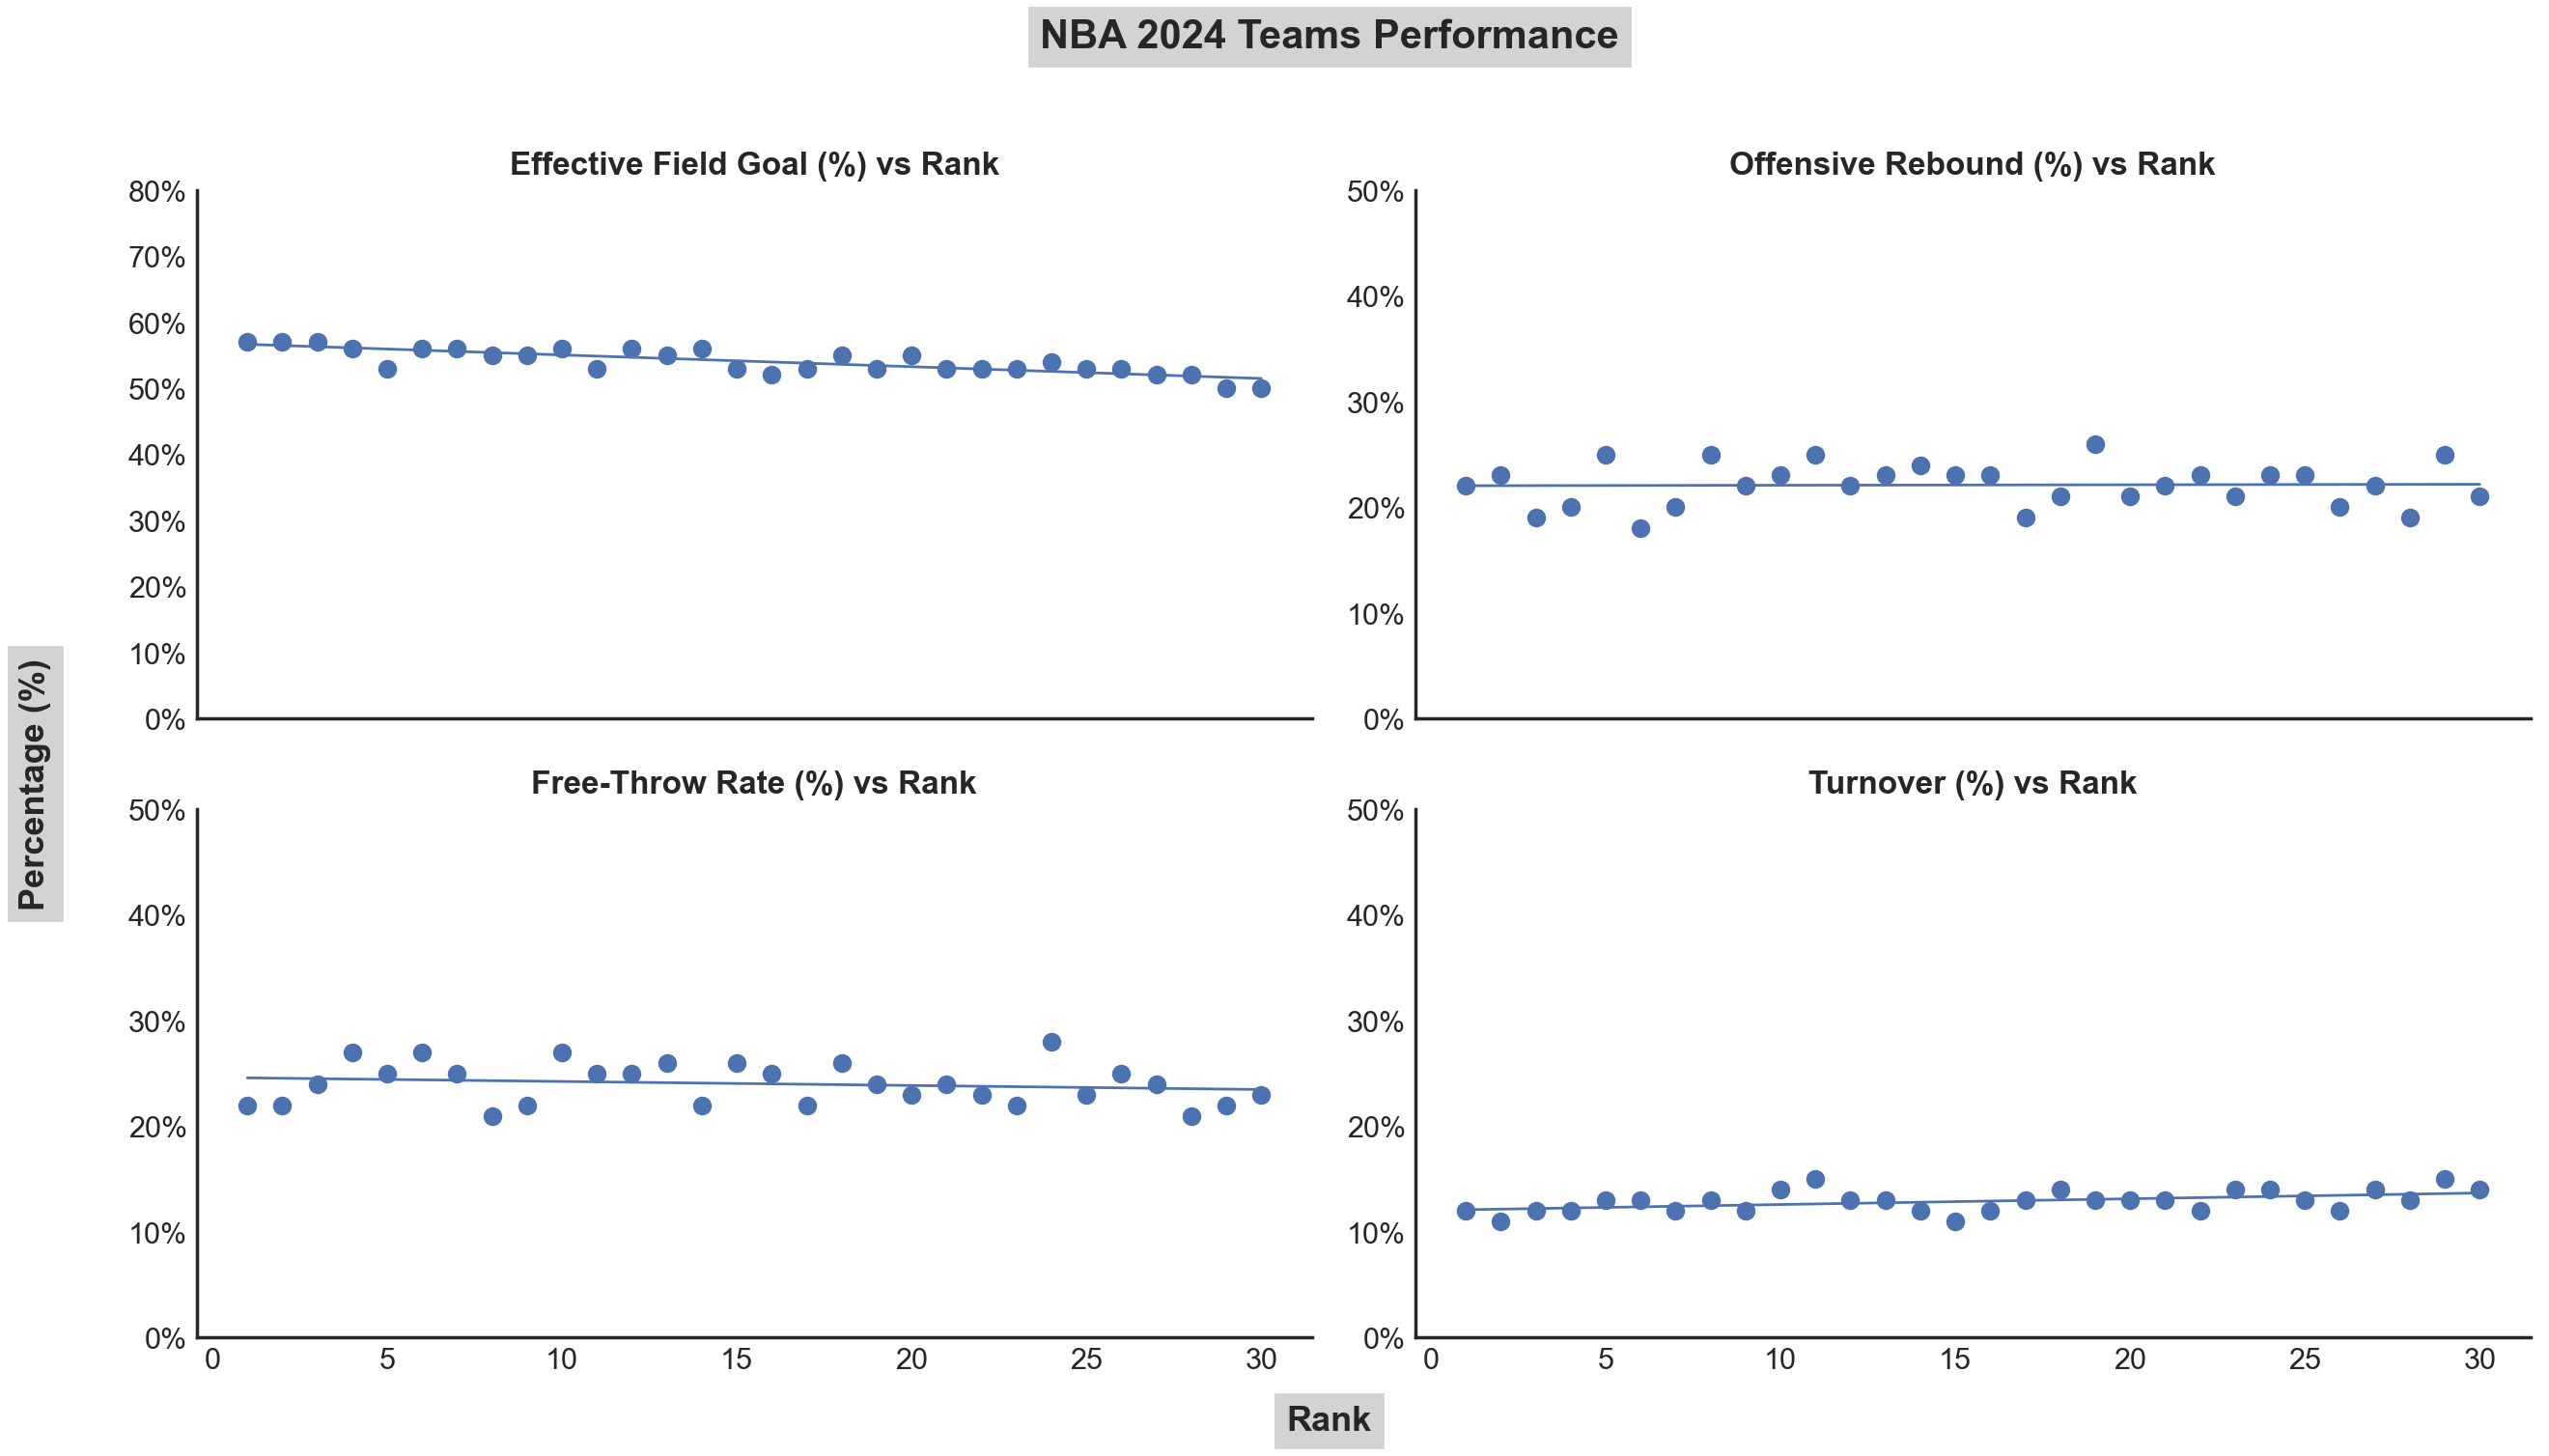

In [113]:
team_performance_metrics(team_2024, 2024)

/var/folders/th/j8z2dhq93093fldk111x3r500000gn/T/ipykernel_52251/1712490526.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(


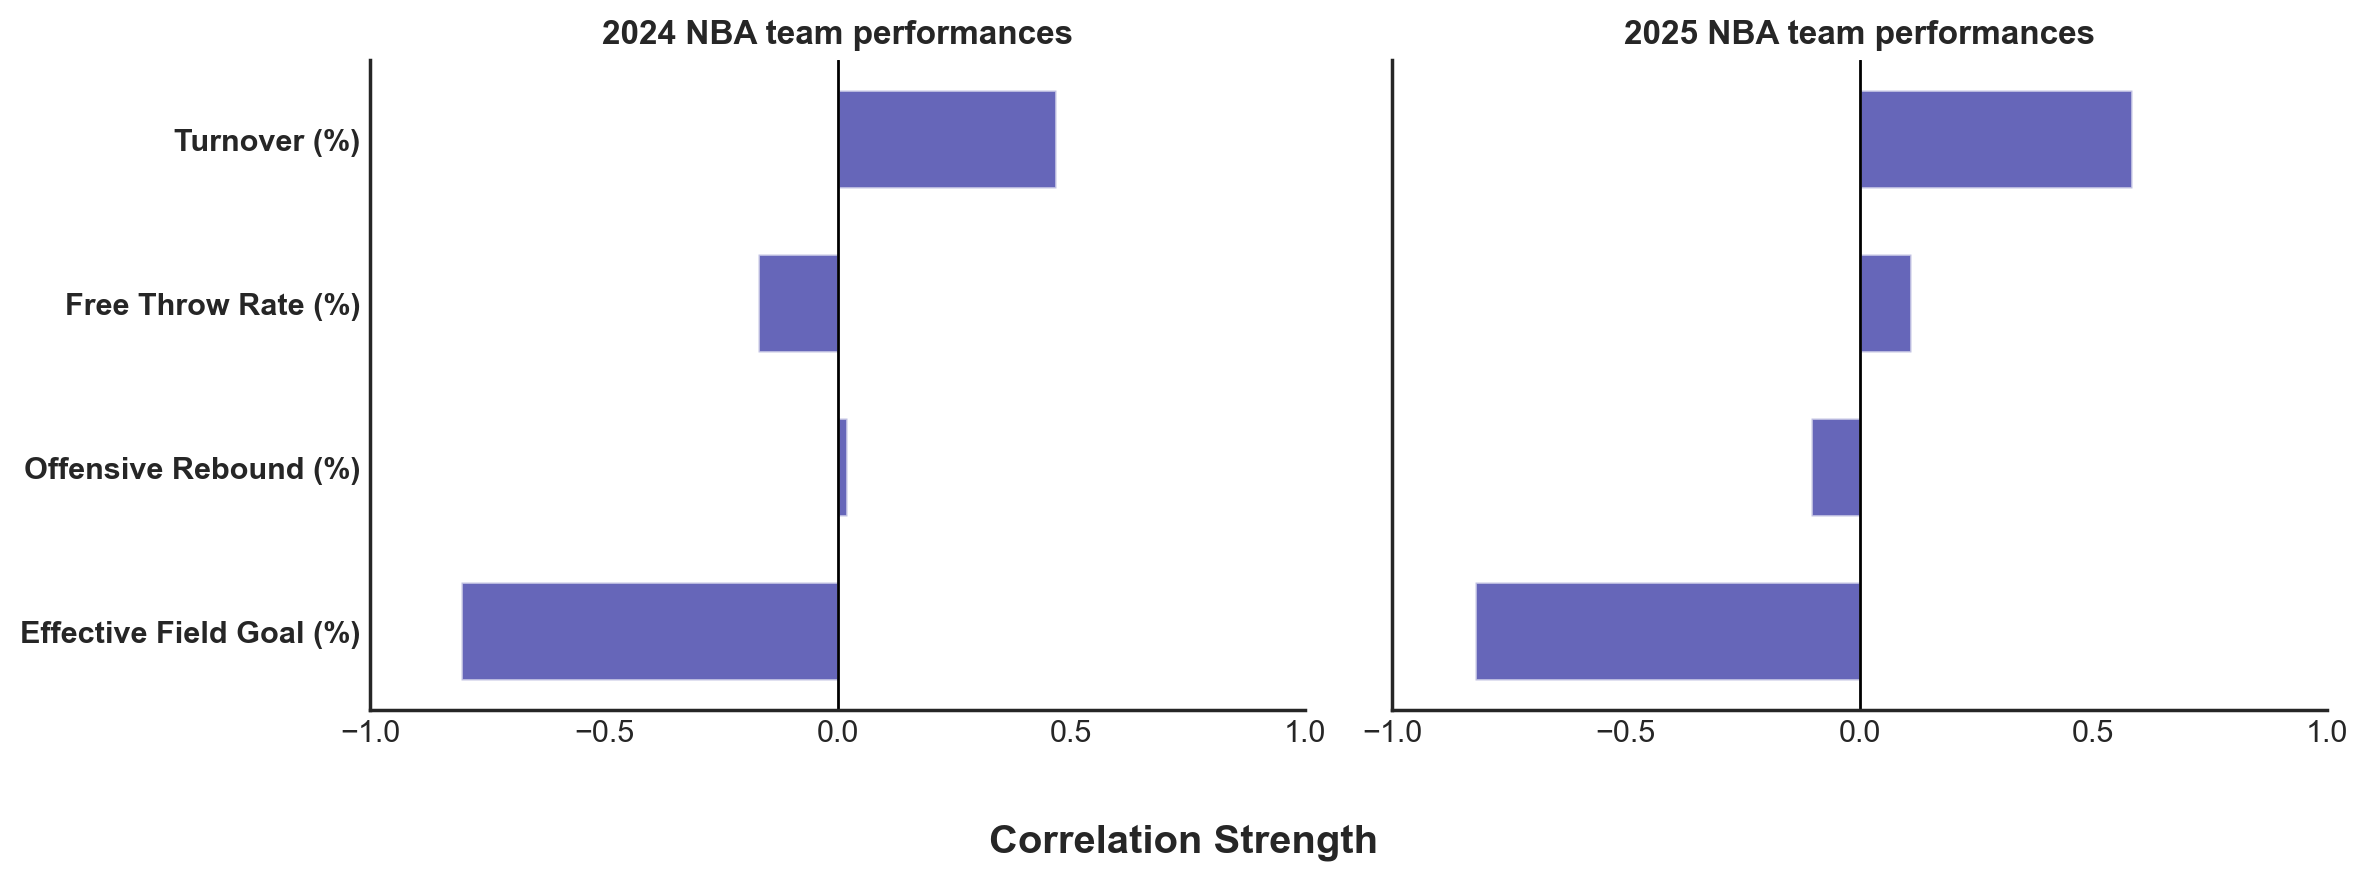

In [114]:
metrics = [
    "effective_fg_percentage",
    "offensive_rebound_pct",
    "free_throw_rate",
    "turnover_pct",
]

corr_2024 = team_2024[metrics].corrwith(team_2024["rank"]).reindex(metrics)
corr_2025 = team_2025[metrics].corrwith(team_2025["rank"]).reindex(metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, sharex=True)

axes[0].barh(metrics, corr_2024, height=0.6, alpha=0.6, color="darkblue")
axes[0].set_title("2024 NBA team performances", fontweight="bold")
axes[0].set_xlabel("Correlation")


axes[1].barh(metrics, corr_2025, height=0.6, alpha=0.6, color="darkblue")
axes[1].set_title("2025 NBA team performances", fontweight="bold")
axes[1].set_xlabel("Correlation")


axes[0].set_yticklabels(
    [
        "Effective Field Goal (%)",
        "Offensive Rebound (%)",
        "Free Throw Rate (%)",
        "Turnover (%)",
    ],
    fontweight="bold",
)


for ax in axes.flatten():
    ax.set_xlim(-1, 1)
    ax.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("")


sns.despine(fig=fig)
fig.tight_layout()
fig.suptitle("Correlation Strength", y=-0.05, fontweight="bold")
plt.show()
